# Custom tiles grid for TTE

In [2]:
pip install contextily

  Using cached contextily-1.6.2-py3-none-any.whl.metadata (2.9 kB)
Using cached contextily-1.6.2-py3-none-any.whl (17 kB)
Note: you may need to restart the kernel to use updated packages.


In [850]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon, Point, MultiPolygon, LineString
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import pyproj
from pyproj import CRS
from shapely.ops import split, unary_union
import contextily as ctx
warnings.filterwarnings('ignore')

In [3]:
def cut_tile_at_antimeridian(tile_row):
    """
    Cut a tile that crosses the antimeridian into separate pieces
    Returns a list of tile dictionaries (may be 1 if no cutting needed)
    """
    geometry = tile_row['geometry']
    original_num = tile_row['original_tile_num']
    
    try:
        # Transform to WGS84 to check for antimeridian crossing
        temp_gdf = gpd.GeoDataFrame([1], geometry=[geometry], crs=target_crs)
        geo_geom = temp_gdf.to_crs('EPSG:4326').geometry.iloc[0]
        
        bounds = geo_geom.bounds
        min_lon, min_lat, max_lon, max_lat = bounds
        lon_span = max_lon - min_lon
        
        # Check if tile crosses antimeridian (spans more than 180 degrees)
        if lon_span > 180:
            #print(f"Cutting tile {original_num} crossing antimeridian (lon span: {lon_span:.1f}°)")
            
            # Create cutting lines at -180 and +180 degrees
            cutting_lines_wgs84 = []
            
            # Add cutting lines where needed
            if min_lon < -180 < max_lon:
                cutting_lines_wgs84.append(LineString([(-180, min_lat - 1), (-180, max_lat + 1)]))
            if min_lon < 0 < max_lon and lon_span > 300:  # Very wide tiles
                cutting_lines_wgs84.append(LineString([(0, min_lat - 1), (0, max_lat + 1)]))
            if min_lon < 180 < max_lon:
                cutting_lines_wgs84.append(LineString([(180, min_lat - 1), (180, max_lat + 1)]))
            
            if cutting_lines_wgs84:
                # Transform cutting lines to Canada Albers
                cuts_gdf = gpd.GeoDataFrame(geometry=cutting_lines_wgs84, crs='EPSG:4326')
                cuts_proj = cuts_gdf.to_crs(target_crs)
                
                # Start with original geometry
                remaining_geom = geometry
                cut_pieces = []
                
                # Apply each cutting line
                for cut_line in cuts_proj.geometry:
                    try:
                        # Use shapely split function to cut the geometry
                        split_result = split(remaining_geom, cut_line)
                        
                        if hasattr(split_result, 'geoms') and len(split_result.geoms) > 1:
                            # Split was successful
                            geoms = list(split_result.geoms)
                            
                            # Take the first piece as cut, continue with the rest
                            if geoms[0].area > geometry.area * 0.01:  # Keep pieces > 1% of original
                                cut_pieces.append(geoms[0])
                            
                            # Continue with remaining pieces
                            if len(geoms) > 1:
                                remaining_geom = unary_union(geoms[1:])
                        
                    except Exception as e:
                        print(f"Error during split operation: {e}")
                        continue
                
                # Add the final remaining piece
                if remaining_geom.area > geometry.area * 0.01:
                    cut_pieces.append(remaining_geom)
                
                # If we got valid cut pieces, return them as separate tiles
                if len(cut_pieces) > 1:
                    result_tiles = []
                    for i, piece in enumerate(cut_pieces):
                        if piece.is_valid and not piece.is_empty:
                            result_tiles.append({
                                'original_tile_num': original_num,
                                'sub_tile_id': i + 1,
                                'geometry': piece,
                                'is_cut': True
                            })
                    
                    if result_tiles:
                        print(f"  Successfully cut into {len(result_tiles)} pieces")
                        return result_tiles
            
            # If cutting failed, try simple bbox splitting
            return split_by_bbox(tile_row)
        
        else:
            # No cutting needed
            return [{
                'original_tile_num': original_num,
                'sub_tile_id': 1,
                'geometry': geometry,
                'is_cut': False
            }]
    
    except Exception as e:
        print(f"Error processing tile {original_num}: {e}")
        return [{
            'original_tile_num': original_num,
            'sub_tile_id': 1,
            'geometry': geometry,
            'is_cut': False
        }]

def split_by_bbox(tile_row):
    """
    Fallback method: split tile by bounding box in geographic coordinates
    """
    geometry = tile_row['geometry']
    original_num = tile_row['original_tile_num']
    
    try:
        # Transform to WGS84
        temp_gdf = gpd.GeoDataFrame([1], geometry=[geometry], crs=target_crs)
        geo_geom = temp_gdf.to_crs('EPSG:4326').geometry.iloc[0]
        
        bounds = geo_geom.bounds
        min_lon, min_lat, max_lon, max_lat = bounds
        
        # Split at 0° longitude if tile spans it and is very wide
        if min_lon < 0 < max_lon and (max_lon - min_lon) > 180:
            # Create two bounding boxes
            west_bbox = Polygon([
                (min_lon, min_lat),
                (0, min_lat),
                (0, max_lat),
                (min_lon, max_lat),
                (min_lon, min_lat)
            ])
            
            east_bbox = Polygon([
                (0, min_lat),
                (max_lon, min_lat),
                (max_lon, max_lat),
                (0, max_lat),
                (0, min_lat)
            ])
            
            # Transform back to Canada Albers and intersect
            bbox_gdf = gpd.GeoDataFrame(geometry=[west_bbox, east_bbox], crs='EPSG:4326')
            bbox_proj = bbox_gdf.to_crs(target_crs)
            
            result_tiles = []
            for i, bbox in enumerate(bbox_proj.geometry):
                intersection = geometry.intersection(bbox)
                if not intersection.is_empty and intersection.is_valid:
                    if intersection.area > geometry.area * 0.05:  # Keep pieces > 5%
                        result_tiles.append({
                            'original_tile_num': original_num,
                            'sub_tile_id': i + 1,
                            'geometry': intersection,
                            'is_cut': True
                        })
            
            if len(result_tiles) > 1:
                #print(f"  Split tile {original_num} using bbox method into {len(result_tiles)} pieces")
                return result_tiles
    
    except Exception as e:
        print(f"Error in bbox splitting: {e}")
    
    # Return original if splitting failed
    return [{
        'original_tile_num': original_num,
        'sub_tile_id': 1,
        'geometry': geometry,
        'is_cut': False
    }]

In [4]:
# Function to assign region
def assign_region(row):
    """Assign region name based on tile centroid coordinates"""
    try:
        geom = row.geometry
        if isinstance(geom, MultiPolygon):
            largest_poly = max(geom.geoms, key=lambda p: p.area)
            centroid_proj = largest_poly.centroid
        else:
            centroid_proj = geom.centroid
        
        centroid_gdf = gpd.GeoDataFrame([1], geometry=[centroid_proj], crs=target_crs)
        centroid_geo = centroid_gdf.to_crs('EPSG:4326')
        centroid_wgs84 = centroid_geo.geometry.iloc[0]
        
        if centroid_wgs84.is_empty or not centroid_wgs84.is_valid:
            return "Invalid"
        
        lon, lat = centroid_wgs84.x, centroid_wgs84.y
        
        # Normalize longitude
        while lon > 180:
            lon -= 360
        while lon < -180:
            lon += 360
        
        if lat < min_latitude or lat > 90:
            return "Invalid"
        
        # Region assignment
        if lat >= 70:
            if -60 <= lon <= 20:
                return "Arctic_Europe"
            elif -170 <= lon <= -60:
                return "Arctic_North_America"
            else:
                return "Arctic_Asia"
        elif lat >= 55:
            if -30 <= lon <= 60:
                return "Northern_Europe"
            elif -170 <= lon <= -50:
                return "Boreal_North_America"
            else:
                return "Boreal_Asia"
        else:
            if -15 <= lon <= 50:
                return "Temperate_Europe"
            elif 50 <= lon <= 180 or -180 <= lon <= -160:
                return "Temperate_Asia"
            elif -160 <= lon <= -50:
                return "Temperate_North_America"
            else:
                return "Other"
                
    except Exception as e:
        return "Invalid"

#### Functions to split tiles on dateline

In [216]:
import geopandas as gpd
from shapely.geometry import MultiPolygon, Polygon, LineString
from shapely.ops import unary_union

def create_date_line_polygon(buffer_distance=0.00001):
    """
    Create a polygon representing the international date line buffered by a given distance.

    Parameters:
    - buffer_distance (float): Distance to buffer the international date line. Default is 0.00005 dd - about 5m in the boreal.

    Returns:
    - geopandas.GeoDataFrame: GeoDataFrame with the buffered international date line polygon.
    """
    # Create a LineString representing the international date line
    date_line = LineString([(-180, -89.99), (-180, 89.99)])

    # Buffer the line to create a polygon
    date_line_polygon = date_line.buffer(buffer_distance)

    # Create a GeoDataFrame with the buffered polygon
    gdf_date_line = gpd.GeoDataFrame(geometry=[date_line_polygon], crs='EPSG:4326')

    return gdf_date_line

def split_polygon(polygon, crs):
    """
    Split a polygon by the international date line.

    Parameters:
    - polygon (shapely.geometry.Polygon): Polygon to be split.

    Returns:
    - List of shapely.geometry.Polygon: List of split polygons.
    """
    date_line = create_date_line_polygon().to_crs(crs).geometry[0]
    
    parts = []
    if polygon.intersects(date_line):
        # Split the polygon
        parts = list(polygon.difference(date_line).geoms) 
    else:
        parts.append(polygon)

    return parts

def split_polygons_by_dateline_poly(gdf, tile_num_col='tile_num', DO_BOREAL_TILES_COLS=False):
    """
    Split polygons in a GeoDataFrame by the international date line.

    Parameters:
    - gdf (geopandas.GeoDataFrame): GeoDataFrame with polygons to be split.

    Returns:
    - geopandas.GeoDataFrame: GeoDataFrame with split polygons.
    """
    # Ensure the GeoDataFrame has a valid geometry column
    if 'geometry' not in gdf.columns or gdf['geometry'].isna().any():
        raise ValueError("The GeoDataFrame must have a valid 'geometry' column with polygons.")

    # Split polygons by the international date line
    split_polygons = []
    centroid_gdf_list = []
    tile_num_list = []
    if 'tile_group' in gdf.columns and 'tile_version' in gdf.columns: DO_BOREAL_TILES_COLS = True
    if DO_BOREAL_TILES_COLS:
        tile_group_list = []
        tile_version_list = []
    for _, row in gdf.iterrows():
        original_polygon = row['geometry']
        tile_num = row[tile_num_col]
        centroid_gdf = gpd.GeoDataFrame(data=[row], geometry=[row['geometry'].centroid], crs=gdf.crs) # this will help carry through attributes
        if original_polygon.geom_type == 'Polygon':
            # Handle a single Polygon
            split_parts = split_polygon(original_polygon, crs=gdf.crs)
        elif original_polygon.geom_type == 'MultiPolygon':
            # Handle MultiPolygon
            split_parts = [split_polygon(part, crs=gdf.crs) for part in original_polygon]
        else:
            raise ValueError(f"Unsupported geometry type: {original_polygon.geom_type}")

        split_polygons.extend(split_parts)
        centroid_gdf_list.append(centroid_gdf)
        for part in split_parts:
            if tile_num in tile_num_list:
                # New split polys are scaled by 100 from original tile_num values
                tile_num = tile_num * 100
            tile_num_list.append(tile_num)
            
            if DO_BOREAL_TILES_COLS:
                tile_group_list.append(row['tile_group'])
                tile_version_list.append(row['tile_version'])

    # Create a new GeoDataFrame with split polygons
    gdf_split = gpd.GeoDataFrame(geometry=split_polygons, crs=gdf.crs)
    gdf_split = gpd.sjoin(gdf_split, pd.concat(centroid_gdf_list), how='left')
    gdf_split[tile_num_col] = tile_num_list
    if DO_BOREAL_TILES_COLS:
        gdf_split['tile_group'] = tile_group_list
        gdf_split['tile_version'] = tile_version_list
    return gdf_split

In [874]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon, Point

def create_polar_circle_filled_correct(min_lat):
    """
    Create a filled circular area representing all area north of 40°N latitude
    """
    
    # Create the outer boundary at 40°N latitude
    outer_lons = np.linspace(-180, 180, 361)
    outer_lats = np.full_like(outer_lons, min_lat)
    
    # Create the outer boundary coordinates
    outer_coords = list(zip(outer_lons, outer_lats))
    
    # To create a FILLED area, we need to define the interior
    # The interior should go up toward the North Pole
    
    # Create interior coordinates that spiral inward toward the pole
    interior_coords = []
    
    # Add concentric circles at higher latitudes
    for lat in [50, 60, 70, 80, 85, 89]:
        # Fewer points as we get closer to pole (avoids distortion)
        n_points = max(36, int(180 * np.cos(np.radians(lat))))
        lons_inner = np.linspace(180, -180, n_points)
        lats_inner = np.full_like(lons_inner, lat)
        interior_coords.extend(list(zip(lons_inner, lats_inner)))
    
    # Add the North Pole
    interior_coords.append((0, 90))
    
    # Now create the polygon correctly:
    # We want ALL the area north of 40°N, so we create coordinates that define this region
    
    # Method 1: Create a "polar cap" polygon
    coords = []
    
    # Start at one point on min_lat°N
    coords.append((-180, min_lat))
    
    # Go around the 40°N circle
    for lon in np.linspace(-180, 180, 361):
        coords.append((lon, min_lat))
    
    # Now we need to "fill in" the area to the north
    # Go to the North Pole via one meridian
    coords.append((180, min_lat))
    coords.append((180, 90))  # Go north along 180° meridian
    coords.append((0, 90))    # North Pole
    coords.append((-180, 90)) # Go to 180°W meridian at pole  
    coords.append((-180, min_lat)) # Back to start
    
    # Create the polygon
    polygon = Polygon(coords)
    
    gdf = gpd.GeoDataFrame([{'region': 'north_of_40N'}], 
                          geometry=[polygon], 
                          crs='EPSG:4326')
    
    return gdf

In [905]:
# Define Canada Albers Equal Area projection
# extra overlap junk in greenland - not bad - but missing needed tiles in kamchatka
hit_lat_albers = CRS.from_proj4('+proj=aea +lat_1=50 +lat_2=70 +lat_0=60 +lon_0=150 +x_0=0 +y_0=0 +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +units=m +no_defs +type=crs').to_proj4()
hit_lat_albers = CRS.from_proj4('+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=350 +x_0=0 +y_0=0 +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +units=m +no_defs +type=crs').to_proj4()

hit_lat_albers


'+proj=aea +lat_0=40 +lon_0=350 +lat_1=50 +lat_2=70 +x_0=0 +y_0=0 +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +units=m +no_defs +type=crs'

In [906]:
# Lambert Azimuthal Equal Area
hit_lat_lambert = CRS.from_proj4("+proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs").to_proj4()
hit_lat_lambert

'+proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs +type=crs'

In [907]:
# Polar Stereographic (better for high latitudes)
proj4_string = "+proj=stere +lat_0=90 +lat_ts=70 +lon_0=180 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
hit_lat_stereo = CRS.from_proj4(proj4_string).to_proj4()
hit_lat_stereo

'+proj=stere +lat_0=90 +lat_ts=70 +lon_0=180 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs +type=crs'

In [908]:
# Boreal Tiles crs
boreal_tiles_albers = gpd.read_file('/projects/my-public-bucket/databank/boreal_tiles_v004_model_ready.gpkg').crs.to_proj4()
boreal_tiles_albers

'+proj=aea +lat_0=40 +lon_0=180 +lat_1=50 +lat_2=70 +x_0=0 +y_0=0 +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +units=m +no_defs +type=crs'

In [909]:
target_crs = CRS.from_proj4(hit_lat_albers)

In [910]:
print(f"Using projection: {target_crs.name}")

# Parameters
tile_size = 120000  # 90km in meters
#min_latitude = 35  # degrees north
output_file = "global_tiles_90km_target_crs.gpkg"
land_buffer_km = 100  # Include tiles within 100km of land
domain_buffer_km = 25

# # Define bounding box (minx, miny, maxx, maxy)
# bbox = (-180, 40, 180, 80)
# # Create a Polygon from the bounding box
# bbox_polygon = box(*bbox)
# # Create a GeoDataFrame with the bounding box
# bbox_gdf = gpd.GeoDataFrame({'geometry': [bbox_polygon]}, crs=4326)

bbox_gdf = create_polar_circle_filled_correct(35)

Using projection: unknown


In [911]:
from shapely.geometry import box

In [912]:
print("Loading world countries for land mask...")
# Load world boundaries to identify land areas
try:
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    print("Loaded world boundaries from naturalearth")
except:
    print("Naturalearth not available, creating simple land approximation")
    land_polygons = [
        Polygon([(-170, 70), (-170, 25), (-50, 25), (-50, 85), (-170, 85), (-170, 70)]),
        Polygon([(-15, 35), (-15, 75), (60, 75), (60, 35), (-15, 35)]),
        Polygon([(60, 35), (60, 85), (180, 85), (180, 35), (60, 35)]),
        Polygon([(170, 50), (170, 75), (-170, 75), (-170, 50), (170, 50)]),
    ]
    world = gpd.GeoDataFrame(geometry=land_polygons, crs='EPSG:4326')

# Create buffered land mask
print(f"Creating {land_buffer_km}km buffer around land areas...")
world_proj = world.to_crs(target_crs)
land_buffer = world_proj.geometry.buffer(land_buffer_km * 1000).unary_union

print(f"Creating {domain_buffer_km}km buffer around domain area...")
# Create world bounds
world_projected = gpd.read_file('/projects/my-public-bucket/databank/world-administrative-boundaries.geojson')#.cx[-180:180,60:75]

# Clip the original GeoDataFrame with the bounding box
world_projected = world_projected.clip(bbox_gdf).to_crs(target_crs)
#world_projected = gpd.read_file('/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp').to_crs(target_crs)
#world_projected = world_projected.assign(geometry=world_projected.geometry.buffer(domain_buffer_km))
domain_buffer = world_projected.geometry.buffer(domain_buffer_km * 1000).unary_union
#world_bounds = Polygon([[-170, min_latitude], [170, min_latitude], [170, 80], [-170, 80], [-170, min_latitude]])
#world_bounds = Polygon([[0, min_latitude], [360, min_latitude], [360, 80], [0, 80], [0, min_latitude]])
#world_gdf = gpd.GeoDataFrame([1], geometry=[world_bounds], crs='EPSG:4326')
#world_projected = world_gdf.to_crs(target_crs)

Loading world countries for land mask...
Naturalearth not available, creating simple land approximation
Creating 100km buffer around land areas...
Creating 25km buffer around domain area...


In [913]:
# Get bounds and create grid
minx, miny, maxx, maxy = world_projected.total_bounds
x_coords = np.arange(minx, maxx + tile_size, tile_size)
y_coords = np.arange(miny, maxy + tile_size, tile_size)

print(f"Creating initial grid: {len(x_coords)-1} x {len(y_coords)-1} = {(len(x_coords)-1) * (len(y_coords)-1)} tiles")

# Create initial grid tiles
tiles = []
original_tile_num = 1

for i in range(len(x_coords) - 1):
    for j in range(len(y_coords) - 1):
        tile_poly = Polygon([
            (x_coords[i], y_coords[j]),
            (x_coords[i+1], y_coords[j]),
            (x_coords[i+1], y_coords[j+1]),
            (x_coords[i], y_coords[j+1]),
            (x_coords[i], y_coords[j])
        ])
        
        if tile_poly.intersects(domain_buffer):
            tiles.append({
                'original_tile_num': original_tile_num,
                'geometry': tile_poly
            })
        
        original_tile_num += 1

print(f"Filtered to {len(tiles)} tiles near land")

Creating initial grid: 108 x 87 = 9396 tiles
Filtered to 5183 tiles near land


In [914]:
# Create GeoDataFrame with tiles
tiles_gdf = gpd.GeoDataFrame(tiles, crs=target_crs)
#tiles_gdf.explore()

In [915]:
# Process all tiles and cut those crossing antimeridian
print("Processing tiles for antimeridian crossing...")
all_cut_tiles = []

for tile_data in tiles:
    cut_results = cut_tile_at_antimeridian(tile_data)
    all_cut_tiles.extend(cut_results)

print(f"After cutting: {len(all_cut_tiles)} total tile pieces")

# Create GeoDataFrame with cut tiles
tiles_gdf = gpd.GeoDataFrame(all_cut_tiles, crs=target_crs)

Processing tiles for antimeridian crossing...
After cutting: 5183 total tile pieces


In [916]:
# Create unique tile numbers
tiles_gdf['tile_num'] = range(1, len(tiles_gdf) + 1)



# Assign regions
print("Assigning regions...")
tiles_gdf['region'] = tiles_gdf.apply(assign_region, axis=1)

# Filter valid tiles
tiles_gdf_valid = tiles_gdf[
    (tiles_gdf['region'] != 'Invalid') & 
    (~tiles_gdf.geometry.is_empty) & 
    (tiles_gdf.geometry.is_valid)
].copy()

print(f"Removed {len(tiles_gdf) - len(tiles_gdf_valid)} invalid tiles")

# Add metadata
tiles_gdf_valid['tile_size_km'] = 90  # Original size
tiles_gdf_valid['area_km2'] = tiles_gdf_valid.geometry.area / 1000000

# Show statistics
cut_tiles = tiles_gdf_valid['is_cut'].sum()
total_tiles = len(tiles_gdf_valid)
print(f"\nTile statistics:")
print(f"  Total tiles: {total_tiles}")
print(f"  Cut tiles: {cut_tiles}")
print(f"  Uncut tiles: {total_tiles - cut_tiles}")

region_summary = tiles_gdf_valid['region'].value_counts()
print(f"\nRegion summary:")
print(region_summary)

# Finalize columns
columns_order = ['tile_num', 'original_tile_num', 'sub_tile_id', 'is_cut', 'region', 'tile_size_km', 'area_km2', 'geometry']
tiles_gdf_final = tiles_gdf_valid[columns_order]

# Save to file
tiles_gdf_final.to_file(output_file, driver='GPKG')
print(f"\nSaved {len(tiles_gdf_final)} tiles to {output_file}")

# Create visualization
print("\nCreating interactive map...")
tiles_wgs84 = tiles_gdf_final.to_crs('EPSG:4326')

# Check for remaining antimeridian issues
dateline_tiles = []
for idx, tile in tiles_wgs84.iterrows():
    bounds = tile.geometry.bounds
    if (bounds[2] - bounds[0]) > 180:
        dateline_tiles.append(idx)

if dateline_tiles:
    print(f"Warning: {len(dateline_tiles)} tiles still span >180° longitude")
else:
    print("✓ No tiles span >180° longitude - should display correctly")

print("\nDone!")

Assigning regions...
Removed 103 invalid tiles

Tile statistics:
  Total tiles: 5080
  Cut tiles: 0
  Uncut tiles: 5080

Region summary:
region
Temperate_North_America    1307
Temperate_Asia              994
Boreal_North_America        677
Boreal_Asia                 634
Northern_Europe             592
Arctic_Asia                 300
Other                       268
Arctic_North_America        161
Arctic_Europe                99
Temperate_Europe             48
Name: count, dtype: int64

Saved 5080 tiles to global_tiles_90km_target_crs.gpkg

Creating interactive map...

Done!


In [917]:
dateline_tiles

[1290,
 1291,
 1335,
 1524,
 1525,
 1555,
 1556,
 1557,
 1586,
 1587,
 1618,
 1619,
 1620,
 1657,
 1658,
 1694,
 1695,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 2168,
 2206,
 2207,
 2208,
 2209,
 2257,
 2258,
 2259,
 2260,
 2309,
 2310,
 2311]

In [918]:
# Display map
m = tiles_gdf_final.explore(
    column="region",
    tooltip=["tile_num", "original_tile_num", "is_cut", "region", "area_km2"],
    style_kwds=dict(fillOpacity=0.4, weight=1),
    tiles="CartoDB positron",
    popup=True
)

display(m)

In [919]:
set(tiles_gdf_final.region.to_list())

{'Arctic_Asia',
 'Arctic_Europe',
 'Arctic_North_America',
 'Boreal_Asia',
 'Boreal_North_America',
 'Northern_Europe',
 'Other',
 'Temperate_Asia',
 'Temperate_Europe',
 'Temperate_North_America'}

In [920]:
#tiles_wgs84[tiles_wgs84.region == 'Boreal_North_America'].explore(m=boreal_tiles.explore(), color='red')

In [ ]:
ax = tiles_gdf_final.boundary.plot()
ctx.add_basemap(ax=ax, attribution=' ', crs=tiles_gdf_final.crs)

### Find antimeridian tiles

In [ ]:
date_line = create_date_line_polygon(buffer_distance=0.00001) # about 1 m in boreal
tiles_dateline = tiles_gdf_final[tiles_gdf_final['tile_num'].isin(dateline_tiles)]

### Split dateline tiles by dateline (test)
##### show for the subset of dateline tiles only (proof of concept)

In [ ]:
# Split polygons by the international date line
tiles_dateline_split = split_polygons_by_dateline_poly(tiles_dateline)

# Fic tile_num col etc
tiles_dateline_split = tiles_dateline_split[tiles_dateline_split['tile_num'].notna()].drop(['index_right'], axis=1)
tiles_dateline_split['tile_num'] = tiles_dateline_split['tile_num'].apply(lambda x: int(x) if x == x else "")


### Map the split tiles  
This shows the fixed tiles! Zoom in at the dateline to inspect.

In [ ]:
tiles_dateline.plot()

### Split ALL tiles by dateline

In [902]:
# Split polygons by the international date line
tiles_gdf_final_split = split_polygons_by_dateline_poly(tiles_gdf_final)

# Fic tile_num col etc
tiles_gdf_final_split = tiles_gdf_final_split[tiles_gdf_final_split['tile_num'].notna()].drop(['index_right'], axis=1)
tiles_gdf_final_split['tile_num'] = tiles_gdf_final_split['tile_num'].apply(lambda x: int(x) if x == x else "")


<Axes: >

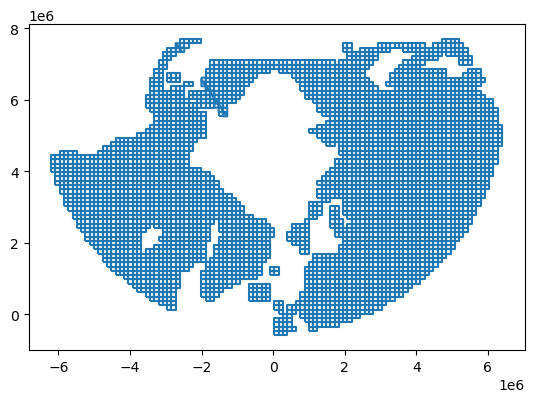

In [903]:
tiles_gdf_final_split.boundary.plot()

In [ ]:
#m = tiles_gdf_final_split[~tiles_gdf_final_split.tile_num.isin([615,616,693,694,695,696,697,698,719,720,721])].explore()
m = tiles_gdf_final_split.explore()
date_line.explore(m=m, color='red')